## The Agent Harness: Bridging the Gap Between Model and Action

An **Agent Harness** is the structural wrapper or "interface layer" that connects a raw Large Language Model (LLM) to the physical resources it needs to function as an autonomous agent.



### The Core Logic
Think of the LLM as the **brain** and the Agent Harness as the **body**—the nervous system, hands, and memory—that allows that brain to interact with the world.

> **Agent = Model + Harness**

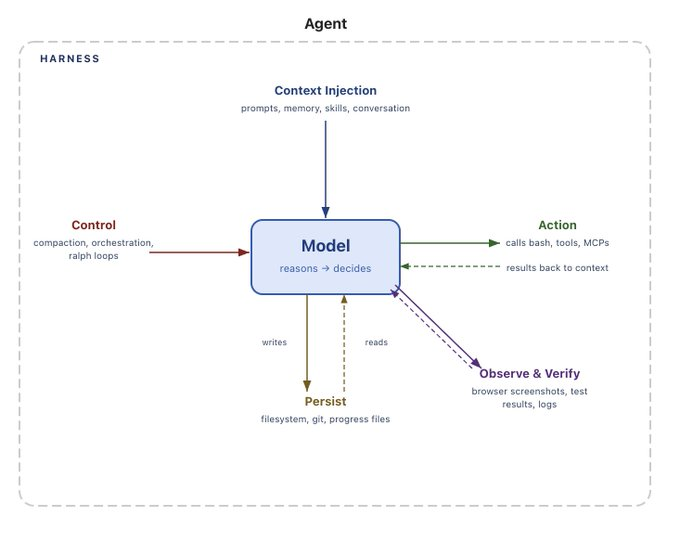

A raw model is not an agent. It becomes one only when a harness provides the essential "connective tissue":

* **State:** Persistent memory across multiple steps.
* **Tool Execution:** The ability to move beyond text and perform actions.
* **Feedback Loops:** Mechanisms to observe results and correct course.
* **Enforceable Constraints:** Guardrails that keep the agent on-mission.

---

### Anatomy of a Harness
Concretely, a robust harness integrates the following components:

| Category | Components |
| :--- | :--- |
| **Cognition** | System Prompts & Global Rules (`AGENTS.md`) |
| **Capabilities** | Tools, Skills, Model Context Protocols (MCPs) |
| **Infrastructure** | Bundled sandboxes, Filesystems, and Browsers |
| **Orchestration** | Sub-agent spawning, handoffs, and model routing |
| **Middleware** | Hooks for lint checks, compaction, and deterministic execution |

---

### Why It Matters
Without the harness, an LLM is a **static predictor**. With the harness, it becomes a **dynamic employee** capable of navigating a workspace, utilizing tools, and achieving complex objectives autonomously.


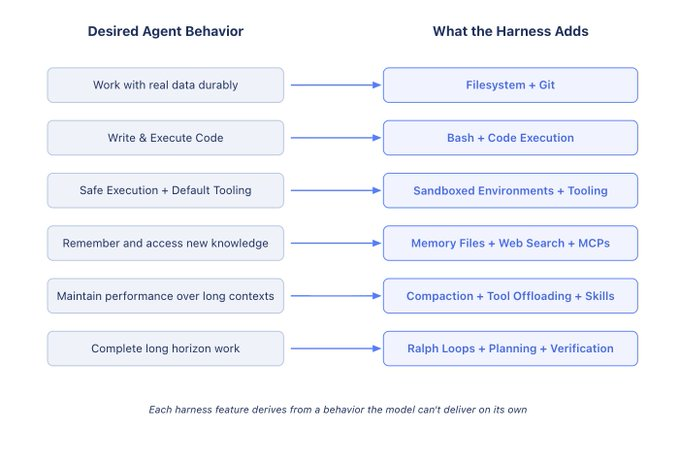

Credit: https://www.langchain.com/blog/the-anatomy-of-an-agent-harness

The Core Difference: AGENTS.md vs. SKILL.md

- AGENTS.md - who the Agent is and how it behaves ?
- SKILL.md - What the agent is capable of doing?
  
- AGENTS.md (The "Who"): Acts as the agent's permanent identity and global rulebook, defining project-wide guardrails.

- SKILL.md (The "How"): Provides specific, step-by-step instructions for a single task that are only loaded when that specific capability is triggered.

- Loading: AGENTS.md is loaded at startup into the system prompt, while SKILL.md is pulled in dynamically via "progressive disclosure."

- Scope: AGENTS.md governs everything the agent does; SKILL.md only governs its behavior during a specialized action.

In [15]:
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langchain_openai import ChatOpenAI

from dotenv import load_dotenv

# Load environment variables from a .env file
load_dotenv()

# 1. Initialize your language model
llm = ChatOpenAI(model="gpt-5-2025-08-07")


In [16]:
from pathlib import Path
BASE_DIR = Path.cwd()
print(BASE_DIR)

/Users/aritrasen/Documents/code/github/agent_harness


In [ ]:
# 2. Give the agent a pluggable filesystem backend so it can read/write files
# This grants the agent tools like read_file, write_file, and ls.
backend = FilesystemBackend(root_dir=str(BASE_DIR))

# 3. Create the Deep Agent harness
agent = create_deep_agent(
    model=llm,
    system_prompt="You are a helpful and autonomous task orchestrator.",

    backend=backend, # Provides the agent with tools to interact with the filesystem
    
    # Loads project-level conventions into the system prompt
    memory=[str(BASE_DIR / "AGENTS.md")],
    
    # Scans the folder, parses YAML frontmatter, and makes skills available to the agent
    skills=[str(BASE_DIR / "skills")] 
)

/var/folders/57/y3hsdcy135b1wr5gzcw3b3kr0000gn/T/ipykernel_55790/80724539.py:3: DeprecationWarning: FilesystemBackend virtual_mode default will change in deepagents 0.5.0; please specify virtual_mode explicitly. Note: virtual_mode is for virtual path semantics (e.g., CompositeBackend routing) and optional path-based guardrails; it does not provide sandboxing or process isolation. Security note: leaving virtual_mode=False allows absolute paths and '..' to bypass root_dir. Consult the API reference for details.
  backend = FilesystemBackend(root_dir=str(BASE_DIR))


In [18]:
# 4. Invoke the agent
if __name__ == "__main__":
    response = agent.invoke({
        "messages": [
            {"role": "user", "content": "I have a long article in /workspace/article.txt. Please summarize it for me."}
        ]
    })
    
print("\n--- Agent Execution Complete ---")


--- Agent Execution Complete ---


In [19]:
print(response['messages'][-1].content)

Saved a summary to /workspace/article_summary.md. Here are the key themes:
- Evolution into a specialized, commercially dominant format: T20 reshaped cricket with a 20-over, prime-time structure that emphasizes power-hitting, innovative bowling, sharp fielding, and strategic depth beyond its early “hit-and-giggle” reputation.
- Tactical sophistication and role specialization: Powerplay optimization (targeting 60+ in first six overs), league-driven innovations like the Impact Player rule, and advanced skillsets—from 360-degree batting to knuckleballs and death-overs yorkers—have raised the technical bar.
- 2026 milestones and global significance: India won the Men’s T20 World Cup (vs New Zealand at Narendra Modi Stadium); IPL 2026 continues to shatter scoring records; qualifiers feature emerging nations (Japan, Indonesia, Germany). The format acts as a cultural bridge, fuels year-round franchise cricket, fits modern attention spans, and drives cricket’s future and Olympic ambitions.


In [20]:
response

{'messages': [HumanMessage(content='I have a long article in /workspace/article.txt. Please summarize it for me.', additional_kwargs={}, response_metadata={}, id='e46a16d1-46f1-4f0a-8a55-cb5bb2eba7aa'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_v0gyUbXdiZyGWzN47QwCSTzO', 'function': {'arguments': '{"file_path":"/Users/aritrasen/Documents/code/github/agent_harness/skills/text-summarizer/SKILL.md", "limit":1000}', 'name': 'read_file'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 500, 'prompt_tokens': 6823, 'total_tokens': 7323, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 448, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DZuWltsPUV8POgJAGK67dvHydKwLW', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs':